In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import fft, fftfreq
from scipy.signal.windows import hamming


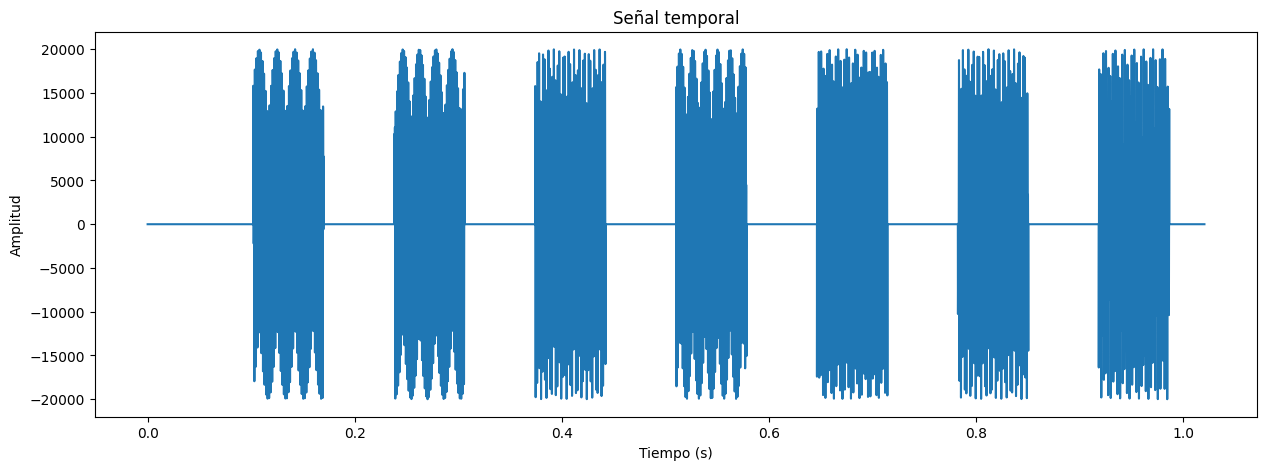

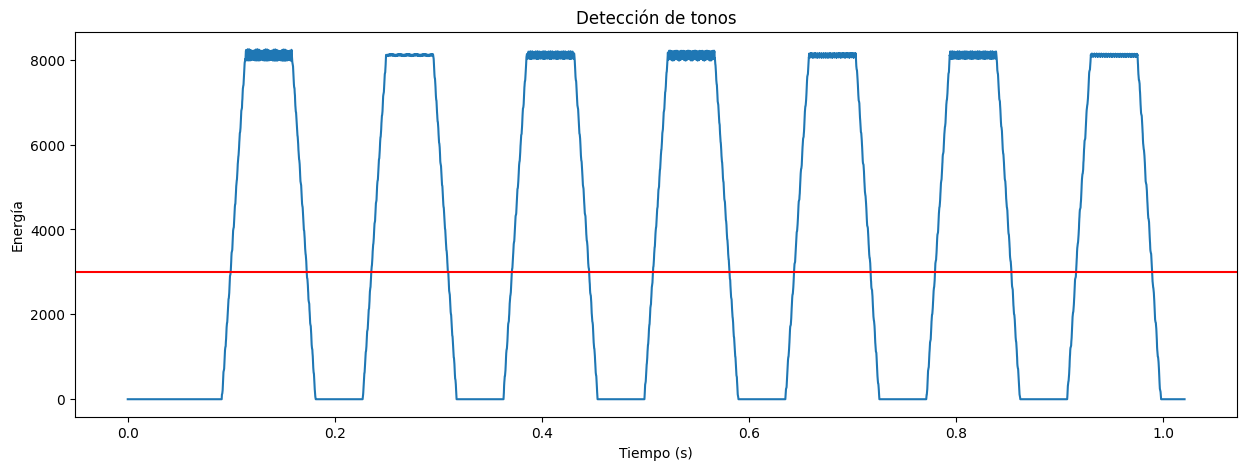

Inicios: [0.09943311 0.23507937 0.370839   0.50709751 0.64324263 0.77938776
 0.91562358]
Finales: [0.17281179 0.30927438 0.44546485 0.58090703 0.71730159 0.85312925
 0.98909297]


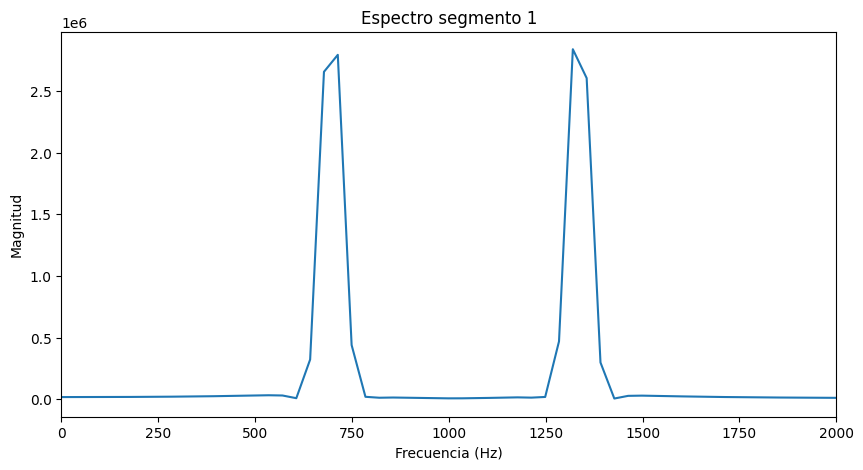

Frecuencia baja detectada: 697
Frecuencia alta detectada: 1336
Dígito detectado: 2


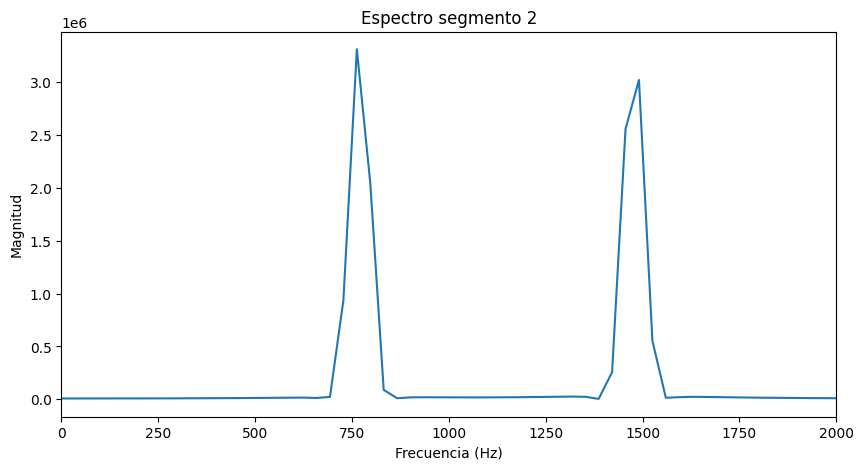

Frecuencia baja detectada: 770
Frecuencia alta detectada: 1477
Dígito detectado: 6


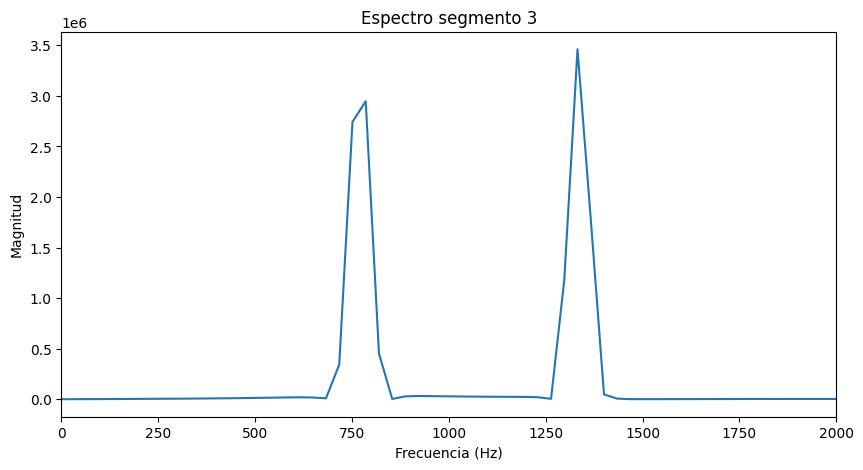

Frecuencia baja detectada: 770
Frecuencia alta detectada: 1336
Dígito detectado: 5


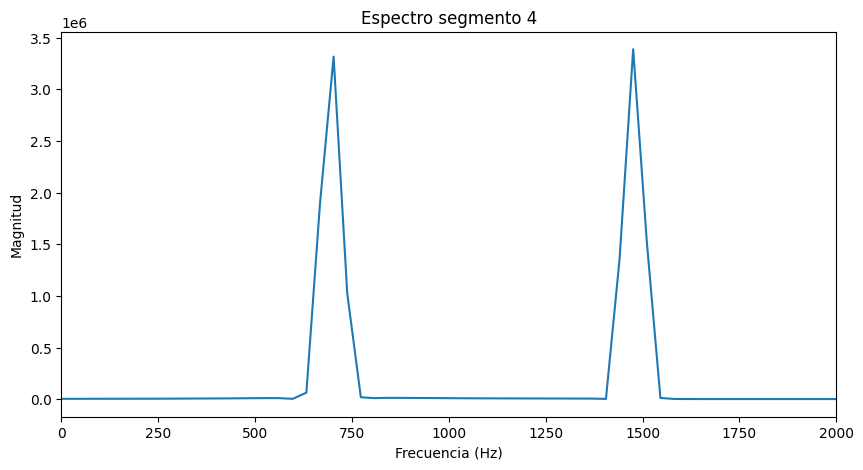

Frecuencia baja detectada: 697
Frecuencia alta detectada: 1477
Dígito detectado: 3


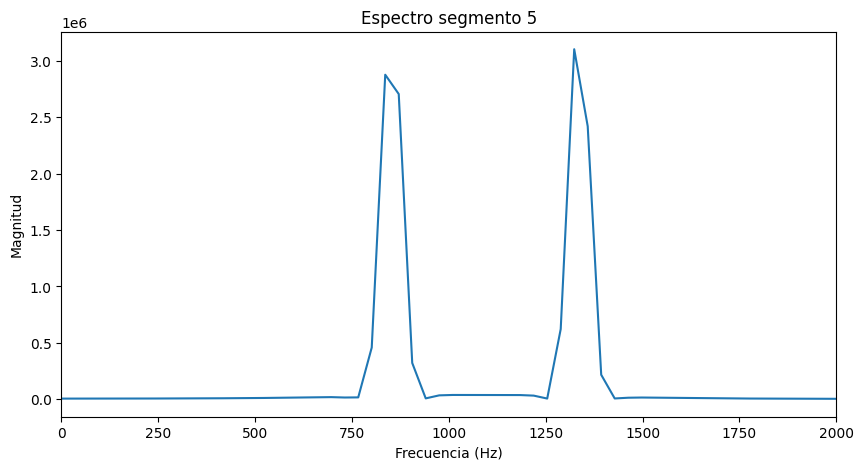

Frecuencia baja detectada: 852
Frecuencia alta detectada: 1336
Dígito detectado: 8


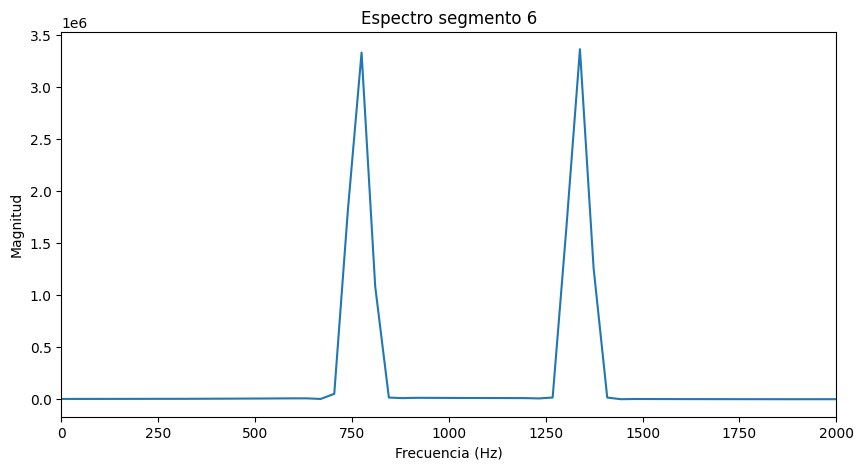

Frecuencia baja detectada: 770
Frecuencia alta detectada: 1336
Dígito detectado: 5


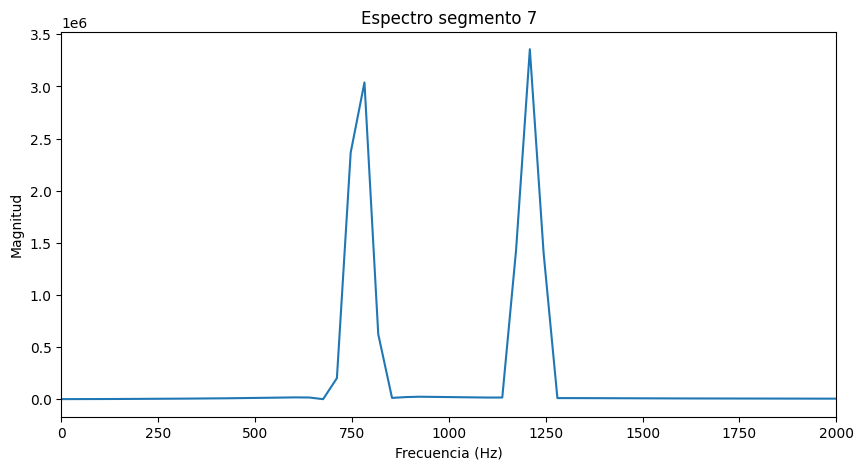

Frecuencia baja detectada: 770
Frecuencia alta detectada: 1209
Dígito detectado: 4
Número detectado: 2653854


In [2]:
# =========================
# Lectura del audio
# =========================

fs_a, audio_a = wavfile.read('tlfn-a.wav')

canal_a = audio_a[:,0]

ta = np.arange(len(canal_a)) / fs_a

# =========================
# Visualización temporal
# =========================

plt.figure(figsize=(15,5))

plt.plot(ta, canal_a)

plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')

plt.title('Señal temporal')

plt.show()

# =========================
# Energía suavizada
# =========================

amplitud = np.abs(canal_a)

ventana = 1000

energia = np.convolve(
    amplitud,
    np.ones(ventana)/ventana,
    mode='same'
)

# =========================
# Detección de tonos
# =========================

umbral = 3000

hay_senal = energia > umbral

plt.figure(figsize=(15,5))

plt.plot(ta, energia)
plt.axhline(umbral, color='red')

plt.xlabel('Tiempo (s)')
plt.ylabel('Energía')

plt.title('Detección de tonos')

plt.show()

# =========================
# Encontrar intervalos
# =========================

cambios = np.diff(hay_senal.astype(int))

inicios = np.where(cambios == 1)[0]
finales = np.where(cambios == -1)[0]

print('Inicios:', inicios/fs_a)
print('Finales:', finales/fs_a)

# =========================
# Frecuencias DTMF conocidas
# =========================

dtmf_bajas = np.array([697, 770, 852, 941])
dtmf_altas = np.array([1209, 1336, 1477])

# =========================
# Tabla DTMF
# =========================

tabla = {
    (697,1209): '1',
    (697,1336): '2',
    (697,1477): '3',

    (770,1209): '4',
    (770,1336): '5',
    (770,1477): '6',

    (852,1209): '7',
    (852,1336): '8',
    (852,1477): '9',

    (941,1209): '*',
    (941,1336): '0',
    (941,1477): '#'
}

# =========================
# Procesamiento de segmentos
# =========================

numero = ''

for i in range(len(inicios)):

    inicio = inicios[i]
    final = finales[i]

    # evitar bordes
    margen = 1000

    segmento = canal_a[inicio+margen : final-margen]

    # =========================
    # Ventana Hamming
    # =========================

    ventana_hamming = hamming(len(segmento))

    segmento = segmento * ventana_hamming

    # =========================
    # FFT
    # =========================

    transformada = fft(segmento)

    frecuencias = fftfreq(len(segmento), d=1/fs_a)

    mitad = len(frecuencias)//2

    frecuencias = frecuencias[:mitad]

    magnitud = np.abs(transformada[:mitad])

    # =========================
    # Gráfico espectral
    # =========================

    plt.figure(figsize=(10,5))

    plt.plot(frecuencias, magnitud)

    plt.xlim(0,2000)

    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')

    plt.title(f'Espectro segmento {i+1}')

    plt.show()

    # =========================
    # Buscar frecuencias DTMF
    # =========================

    energias_bajas = []

    for f in dtmf_bajas:

        indice = np.argmin(np.abs(frecuencias - f))

        energias_bajas.append(magnitud[indice])

    energias_altas = []

    for f in dtmf_altas:

        indice = np.argmin(np.abs(frecuencias - f))

        energias_altas.append(magnitud[indice])

    # frecuencia baja dominante
    freq_baja = dtmf_bajas[np.argmax(energias_bajas)]

    # frecuencia alta dominante
    freq_alta = dtmf_altas[np.argmax(energias_altas)]

    print(f'Frecuencia baja detectada: {freq_baja}')
    print(f'Frecuencia alta detectada: {freq_alta}')

    # =========================
    # Reconocimiento del dígito
    # =========================

    digito = tabla[(freq_baja, freq_alta)]

    print(f'Dígito detectado: {digito}')

    numero += digito

print(f'Número detectado: {numero}')

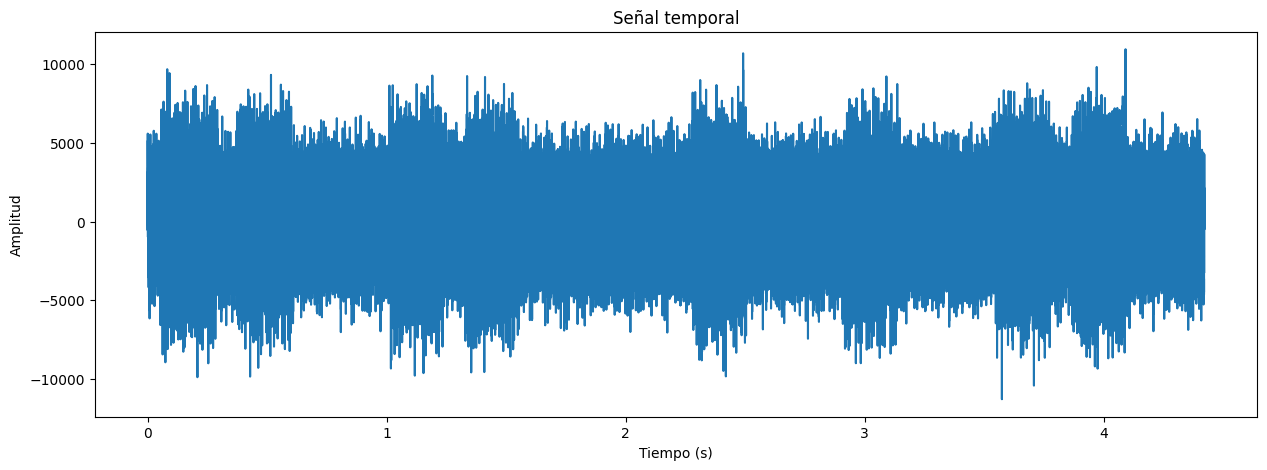

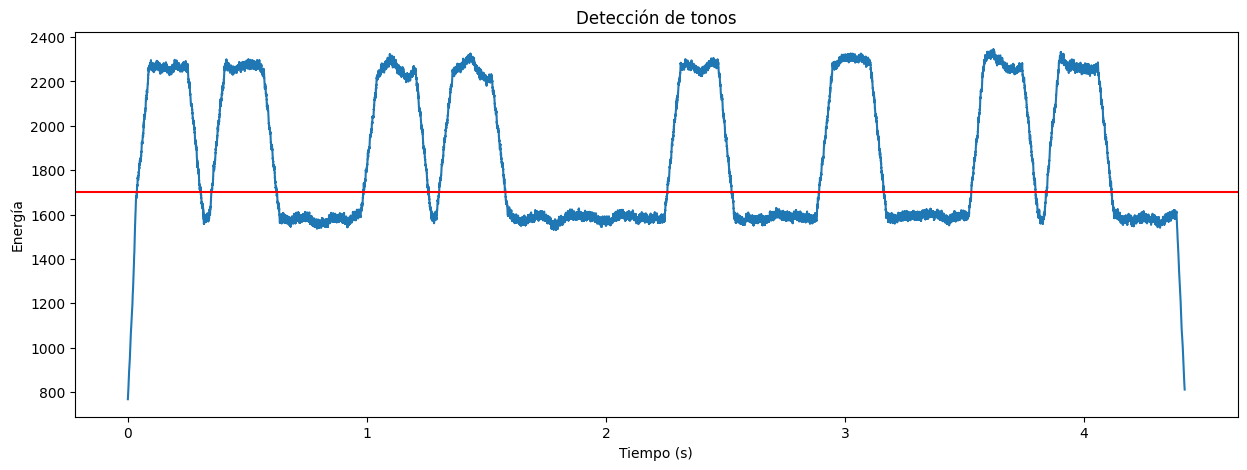

Inicios: [0.03725624 0.34936508 0.98537415 1.30244898 2.25698413 2.89208617
 3.52888889 3.84412698]
Finales: [0.30507937 0.6224263  1.25630385 1.57968254 2.52578231 3.16276644
 3.79768707 4.11609977]


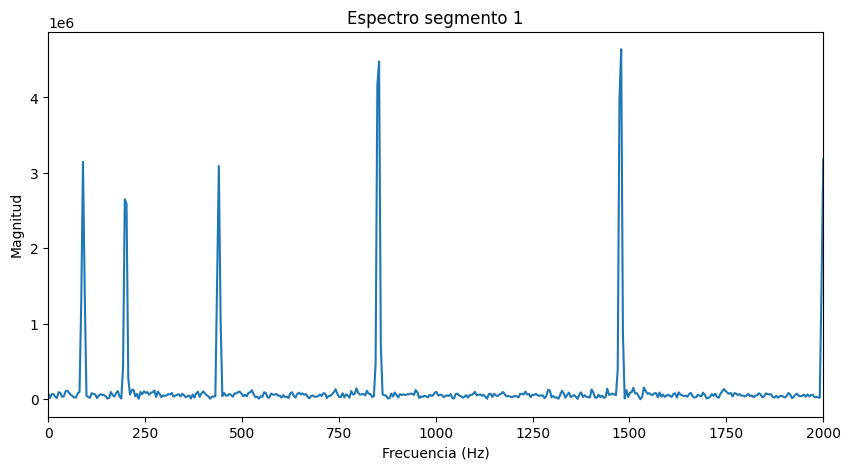

Frecuencia baja detectada: 852
Frecuencia alta detectada: 1477
Dígito detectado: 9


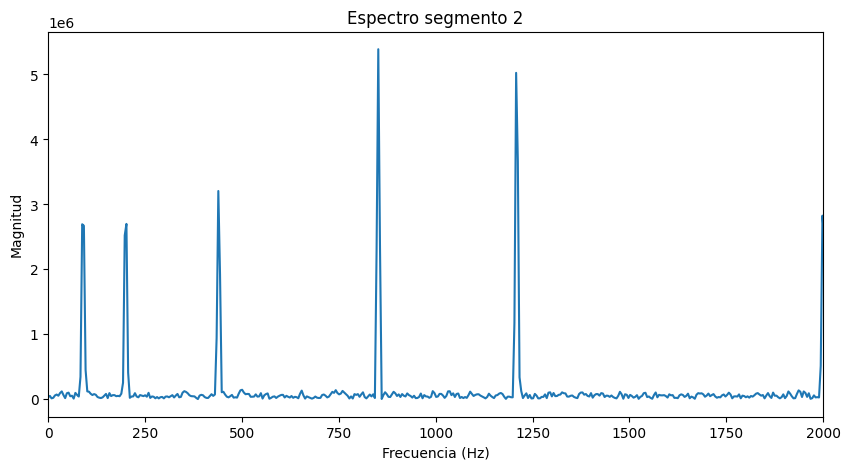

Frecuencia baja detectada: 852
Frecuencia alta detectada: 1209
Dígito detectado: 7


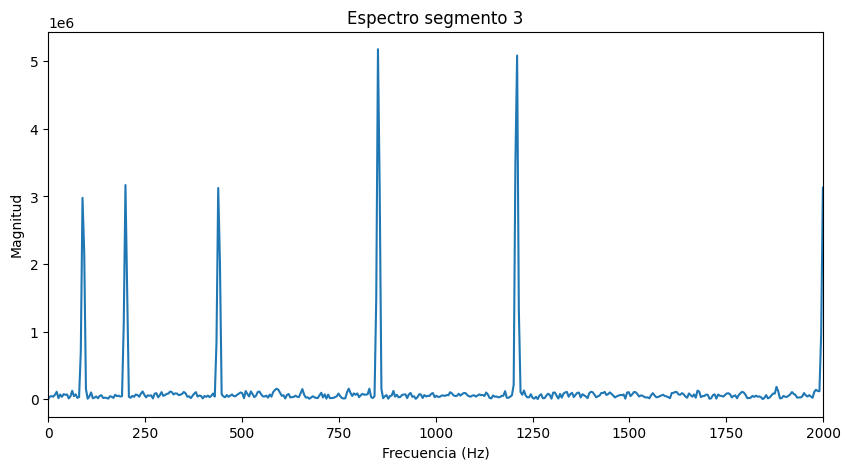

Frecuencia baja detectada: 852
Frecuencia alta detectada: 1209
Dígito detectado: 7


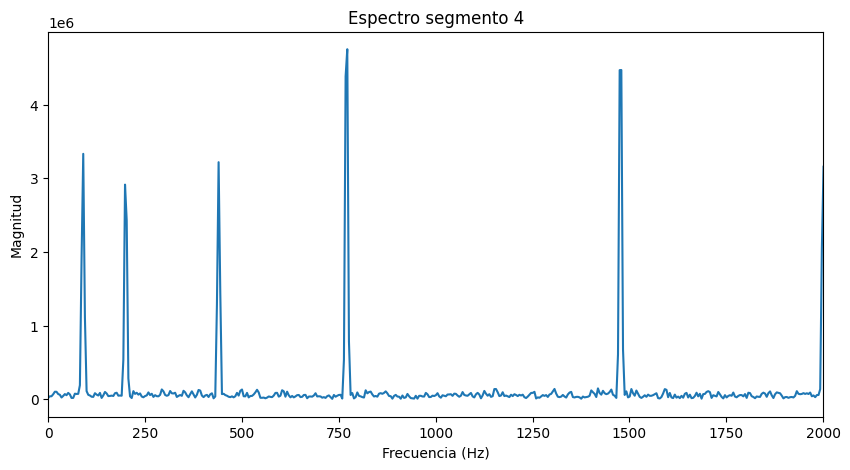

Frecuencia baja detectada: 770
Frecuencia alta detectada: 1477
Dígito detectado: 6


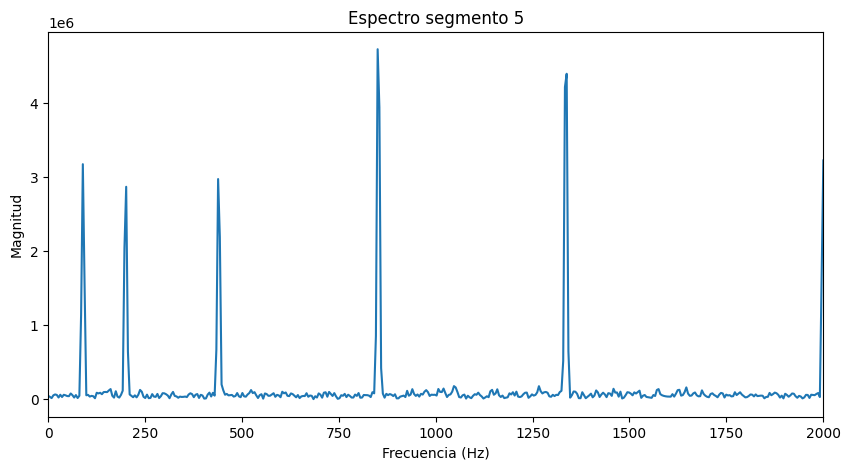

Frecuencia baja detectada: 852
Frecuencia alta detectada: 1336
Dígito detectado: 8


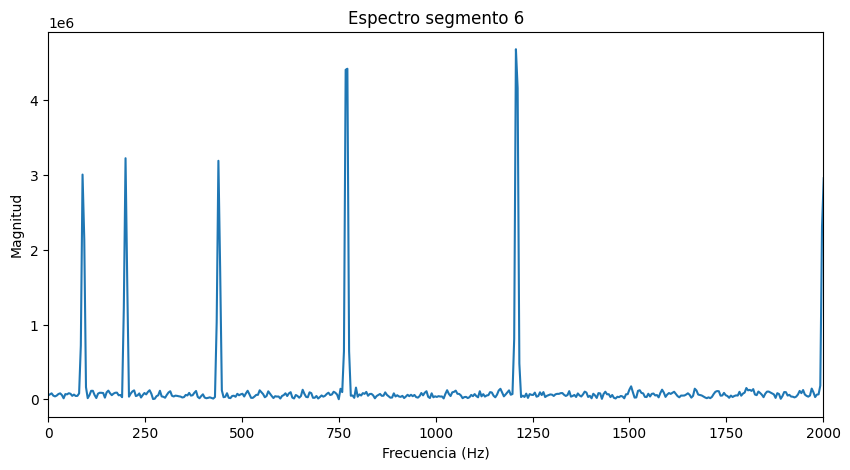

Frecuencia baja detectada: 770
Frecuencia alta detectada: 1209
Dígito detectado: 4


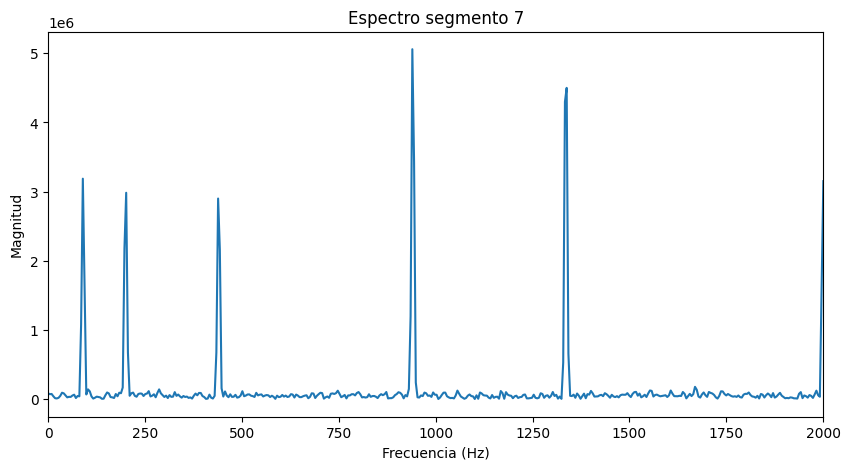

Frecuencia baja detectada: 941
Frecuencia alta detectada: 1336
Dígito detectado: 0


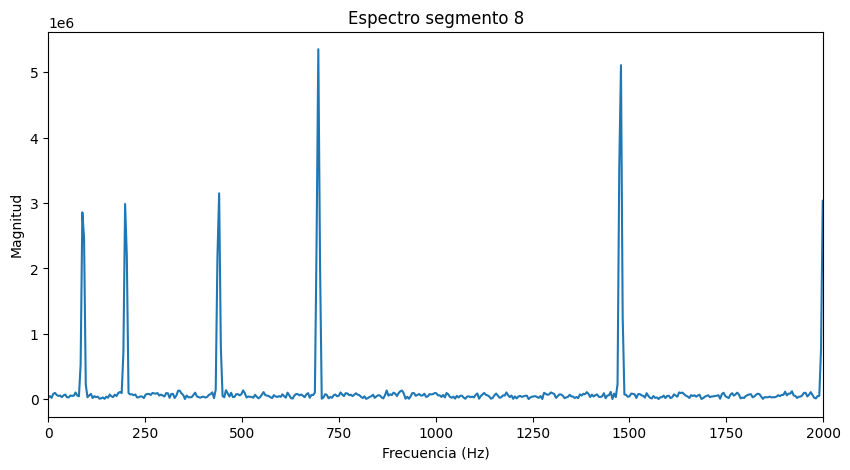

Frecuencia baja detectada: 697
Frecuencia alta detectada: 1477
Dígito detectado: 3
Número detectado: 97768403


In [4]:
# =========================
# Lectura del audio
# =========================

fs_b, audio_b = wavfile.read('tlfn-b.wav')

canal_b = audio_b[:,0]

tb = np.arange(len(canal_b)) / fs_b

# =========================
# Visualización temporal
# =========================

plt.figure(figsize=(15,5))

plt.plot(tb, canal_b)

plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')

plt.title('Señal temporal')

plt.show()

# =========================
# Energía suavizada
# =========================

amplitud = np.abs(canal_b)

ventana = 3000

energia = np.convolve(
    amplitud,
    np.ones(ventana)/ventana,
    mode='same'
)

# =========================
# Detección de tonos
# =========================

umbral = 1700

hay_senal = energia > umbral

plt.figure(figsize=(15,5))

plt.plot(tb, energia)
plt.axhline(umbral, color='red')

plt.xlabel('Tiempo (s)')
plt.ylabel('Energía')

plt.title('Detección de tonos')

plt.show()

# =========================
# Encontrar intervalos
# =========================

cambios = np.diff(hay_senal.astype(int))

inicios = np.where(cambios == 1)[0]
finales = np.where(cambios == -1)[0]

duracion_minima = 0.05   # segundos

inicios_filtrados = []
finales_filtrados = []

for inicio, final in zip(inicios, finales):

    duracion = (final - inicio) / fs_b

    if duracion > duracion_minima:

        inicios_filtrados.append(inicio)
        finales_filtrados.append(final)

inicios = np.array(inicios_filtrados)
finales = np.array(finales_filtrados)

tiempos_inicio = inicios / fs_a
tiempos_final = finales / fs_a

print('Inicios:', inicios/fs_a)
print('Finales:', finales/fs_a)

# =========================
# Frecuencias DTMF conocidas
# =========================

dtmf_bajas = np.array([697, 770, 852, 941])
dtmf_altas = np.array([1209, 1336, 1477])

# =========================
# Tabla DTMF
# =========================

tabla = {
    (697,1209): '1',
    (697,1336): '2',
    (697,1477): '3',

    (770,1209): '4',
    (770,1336): '5',
    (770,1477): '6',

    (852,1209): '7',
    (852,1336): '8',
    (852,1477): '9',

    (941,1209): '*',
    (941,1336): '0',
    (941,1477): '#'
}

# =========================
# Procesamiento de segmentos
# =========================

numero = ''

for i in range(len(inicios)):

    inicio = inicios[i]
    final = finales[i]

    # evitar bordes
    margen = 1000

    segmento = canal_b[inicio+margen : final-margen]

    # =========================
    # Ventana Hamming
    # =========================

    ventana_hamming = hamming(len(segmento))

    segmento = segmento * ventana_hamming

    # =========================
    # FFT
    # =========================

    transformada = fft(segmento)

    frecuencias = fftfreq(len(segmento), d=1/fs_b)

    mitad = len(frecuencias)//2

    frecuencias = frecuencias[:mitad]

    magnitud = np.abs(transformada[:mitad])

    # =========================
    # Gráfico espectral
    # =========================

    plt.figure(figsize=(10,5))

    plt.plot(frecuencias, magnitud)

    plt.xlim(0,2000)

    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')

    plt.title(f'Espectro segmento {i+1}')

    plt.show()

    # =========================
    # Buscar frecuencias DTMF
    # =========================

    energias_bajas = []

    for f in dtmf_bajas:

        indice = np.argmin(np.abs(frecuencias - f))

        energias_bajas.append(magnitud[indice])

    energias_altas = []

    for f in dtmf_altas:

        indice = np.argmin(np.abs(frecuencias - f))

        energias_altas.append(magnitud[indice])

    # frecuencia baja dominante
    freq_baja = dtmf_bajas[np.argmax(energias_bajas)]

    # frecuencia alta dominante
    freq_alta = dtmf_altas[np.argmax(energias_altas)]

    print(f'Frecuencia baja detectada: {freq_baja}')
    print(f'Frecuencia alta detectada: {freq_alta}')

    # =========================
    # Reconocimiento del dígito
    # =========================

    digito = tabla[(freq_baja, freq_alta)]

    print(f'Dígito detectado: {digito}')

    numero += digito

print(f'Número detectado: {numero}')